# Projet Tinder — Speed Dating Analysis
### Qu'est-ce qui incite les gens à accepter un second rendez-vous ?

**Source :** Columbia Business School — Speed Dating Experiment (2002–2004)  
**Objectif :** Analyser les facteurs qui influencent la décision de se revoir après un speed dating de 4 minutes.  
**Livrable :** Jedha Bootcamp — Bloc de certification n°2

---

## Plan de l'analyse

| Étape | Contenu |
|-------|---------|
| **1. Exploration & Nettoyage** | Chargement, structure, valeurs manquantes, stats descriptives |
| **2. Facteurs de match** | Corrélations, comparaison hommes/femmes |
| **3. Questions clés** | Déclaré vs réel, intérêts vs race, auto-évaluation, effet de l'ordre |
| **4. Synthèse** | Conclusions et recommandations |

---


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Palette cohérente
COLORS = {
    'tinder'  : '#E8174A',
    'coral'   : '#F96167',
    'gold'    : '#F9C74F',
    'teal'    : '#4ECDC4',
    'blue'    : '#4A90E2',
    'pink'    : '#FF6B9D',
    'purple'  : '#9B59B6',
    'green'   : '#2ECC71',
    'muted'   : '#95A5A6',
    'dark'    : '#2C3E50',
}

df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin-1')
print(f"   Dataset chargé : {df.shape[0]:,} interactions × {df.shape[1]} colonnes")
print(f"   Participants uniques : {df['iid'].nunique()}")
print(f"   Sessions (waves) : {df['wave'].nunique()}")


   Dataset chargé : 8,378 interactions × 195 colonnes
   Participants uniques : 551
   Sessions (waves) : 21


## Étape 1 — Exploration & Nettoyage des données


### 1.1 Structure du dataset

In [2]:
# Types de colonnes
print("Types de données :")
print(df.dtypes.value_counts())
print()

# Aperçu des colonnes clés
key_cols = ['iid', 'gender', 'match', 'dec', 'dec_o',
            'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like',
            'age', 'samerace', 'int_corr', 'order', 'position']
df[key_cols].head(5)


Types de données :
float64    174
int64       13
str          8
Name: count, dtype: int64



,iid,gender,match,dec,dec_o,attr,sinc,intel,fun,amb,shar,like,age,samerace,int_corr,order,position
0,1,0,0,1,0,6.0,9.0,7.0,7.0,6.0,5.0,7.0,21.0,0,0.14,4,7
1,1,0,0,1,0,7.0,8.0,7.0,8.0,5.0,6.0,7.0,21.0,0,0.54,3,7
2,1,0,1,1,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,21.0,1,0.16,10,7
3,1,0,1,1,1,7.0,6.0,8.0,7.0,6.0,8.0,7.0,21.0,0,0.61,5,7
4,1,0,1,1,1,5.0,6.0,7.0,7.0,6.0,6.0,6.0,21.0,0,0.21,7,7


### 1.2 Valeurs manquantes

On analyse les colonnes clés pour l'analyse — celles avec >75% de NaN (suivis post-soirée) sont exclues.


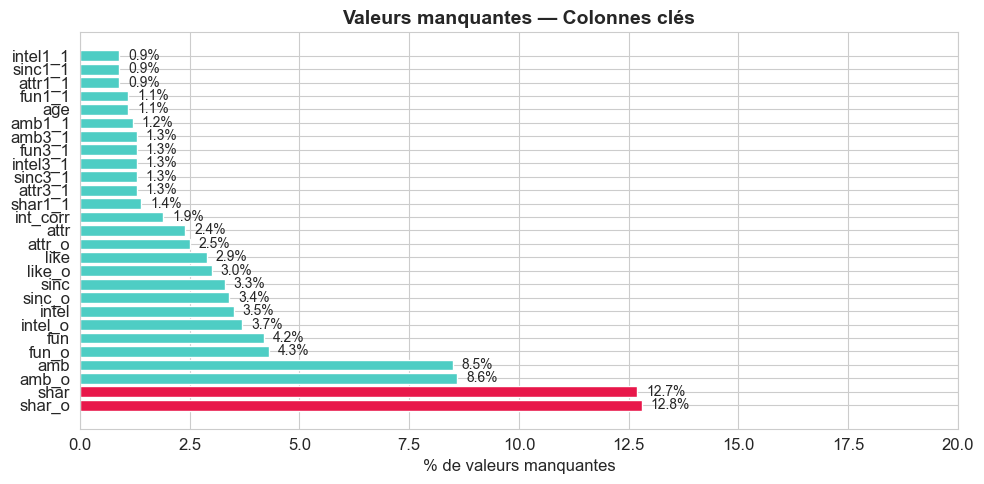

Stratégie : dropna() local par analyse. Aucune ligne supprimée globalement.


In [3]:
analysis_cols = ['attr','sinc','intel','fun','amb','shar','like',
                  'attr_o','sinc_o','intel_o','fun_o','amb_o','shar_o','like_o',
                  'int_corr','age','samerace','order','position',
                  'attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1',
                  'attr3_1','sinc3_1','intel3_1','fun3_1','amb3_1']

missing = df[analysis_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
missing_df = missing_df[missing_df['%'] > 0].sort_values('%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['tinder'] if v > 10 else COLORS['teal'] for v in missing_df['%']]
bars = ax.barh(missing_df.index, missing_df['%'], color=colors, edgecolor='white')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes — Colonnes clés', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_df['%']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlim(0, 20)
plt.tight_layout()
plt.show()

print("Stratégie : dropna() local par analyse. Aucune ligne supprimée globalement.")


### 1.3 Statistiques descriptives

Les 6 critères d'évaluation (attractivité, sincérité, intelligence, humour, ambition, intérêts communs) sont notés de 0 à 10.


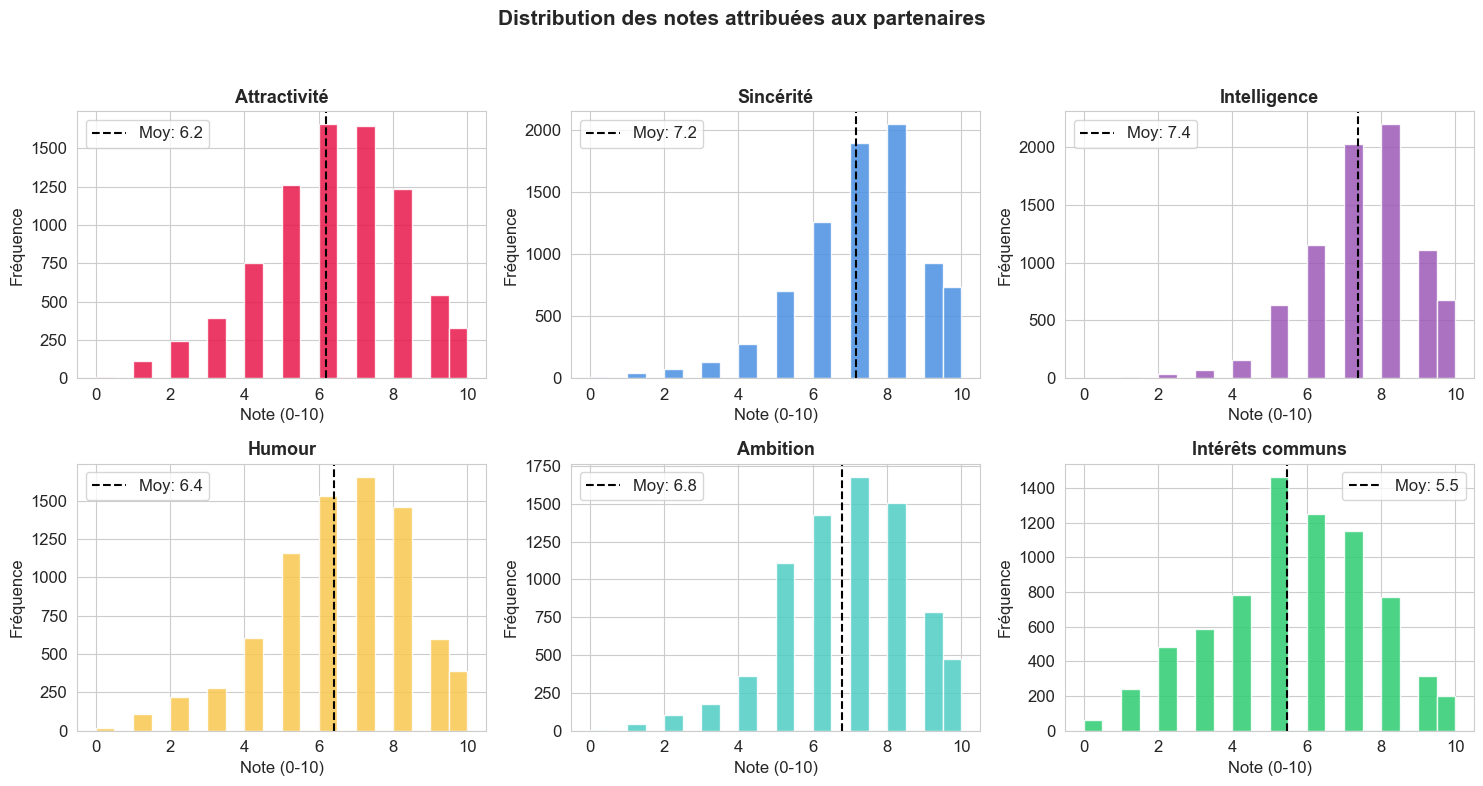

,Attractivité,Sincérité,Intelligence,Humour,Ambition,Intérêts communs
Obs,8176.00,8101.00,8082.00,8028.00,7666.00,7311.00
Moyenne,6.19,7.18,7.37,6.40,6.78,5.47
Écart-type,1.95,1.74,1.55,1.95,1.79,2.16
Min,0.00,0.00,0.00,0.00,0.00,0.00
Q1,5.00,6.00,6.00,5.00,6.00,4.00
Médiane,6.00,7.00,7.00,7.00,7.00,6.00
Q3,8.00,8.00,8.00,8.00,8.00,7.00
Max,10.00,10.00,10.00,10.00,10.00,10.00


In [4]:
criteres = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels   = ['Attractivité', 'Sincérité', 'Intelligence', 'Humour', 'Ambition', 'Intérêts communs']
pal      = [COLORS['tinder'], COLORS['blue'], COLORS['purple'],
            COLORS['gold'], COLORS['teal'], COLORS['green']]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(criteres, labels, pal)):
    data = df[col].dropna()
    axes[i].hist(data, bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Moy: {data.mean():.1f}')
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Note (0-10)')
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

plt.suptitle('Distribution des notes attribuées aux partenaires', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tableau stats
stats = df[criteres].describe().round(2)
stats.index = ['Obs', 'Moyenne', 'Écart-type', 'Min', 'Q1', 'Médiane', 'Q3', 'Max']
stats.columns = labels
stats


### 1.4 Taux de match & décisions par genre

> **match** = 1 si les deux participants ont dit "oui" simultanément  
> **dec** = décision individuelle du participant (0=non, 1=oui)  
> **gender** : 0 = femme, 1 = homme


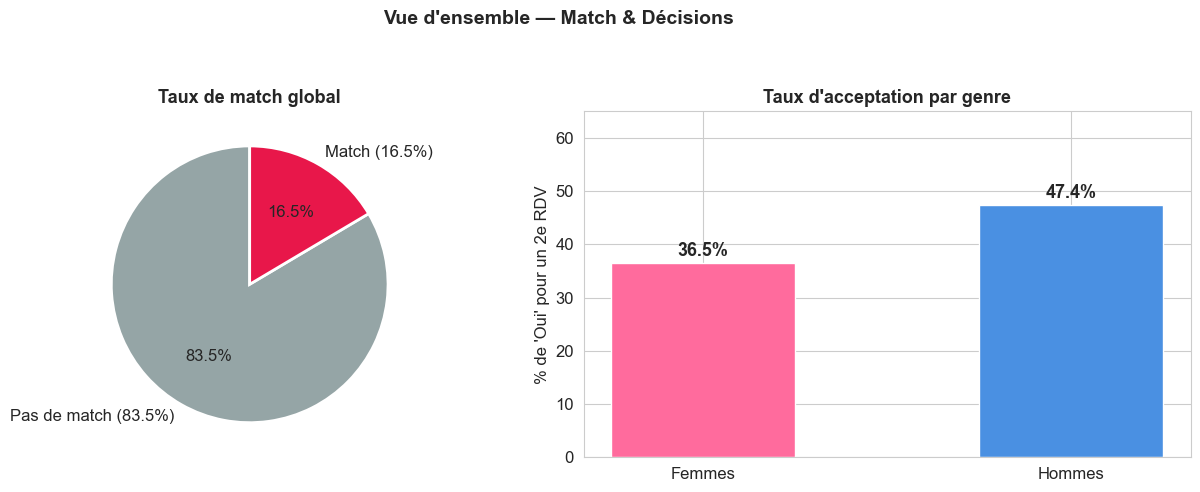

Taux de match global     : 16.5%
Décision 'oui' — Femmes  : 36.5%
Décision 'oui' — Hommes  : 47.4%

Lecture : un match nécessite que les DEUX disent 'oui' simultanément.
Les hommes acceptent ~11 pts de plus → la sélectivité féminine est le principal filtre du match.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart match global
match_counts = df['match'].value_counts()
axes[0].pie(match_counts, labels=['Pas de match (83.5%)', 'Match (16.5%)'],
            colors=[COLORS['muted'], COLORS['tinder']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Taux de match global', fontsize=13, fontweight='bold')

# Taux décision par genre
dec_by_gender = df.groupby('gender')['dec'].mean() * 100
axes[1].bar(['Femmes', 'Hommes'], dec_by_gender.values,
            color=[COLORS['pink'], COLORS['blue']], width=0.5, edgecolor='white')
axes[1].set_ylabel("% de 'Oui' pour un 2e RDV")
axes[1].set_title("Taux d'acceptation par genre", fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 65)
for i, val in enumerate(dec_by_gender.values):
    axes[1].text(i, val + 1.2, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.suptitle("Vue d'ensemble — Match & Décisions", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f"Taux de match global     : {df['match'].mean()*100:.1f}%")
print(f"Décision 'oui' — Femmes  : {df[df['gender']==0]['dec'].mean()*100:.1f}%")
print(f"Décision 'oui' — Hommes  : {df[df['gender']==1]['dec'].mean()*100:.1f}%")
print()
print("Lecture : un match nécessite que les DEUX disent 'oui' simultanément.")
print("Les hommes acceptent ~11 pts de plus → la sélectivité féminine est le principal filtre du match.")


## Étape 2 — Analyse des facteurs de match


### 2.1 Quels critères influencent le plus la décision ?

On calcule la **corrélation de Pearson** entre chaque note attribuée au partenaire et la décision individuelle (`dec`).  
Plus `r` est élevé, plus ce critère pèse dans la décision de revoir le partenaire.


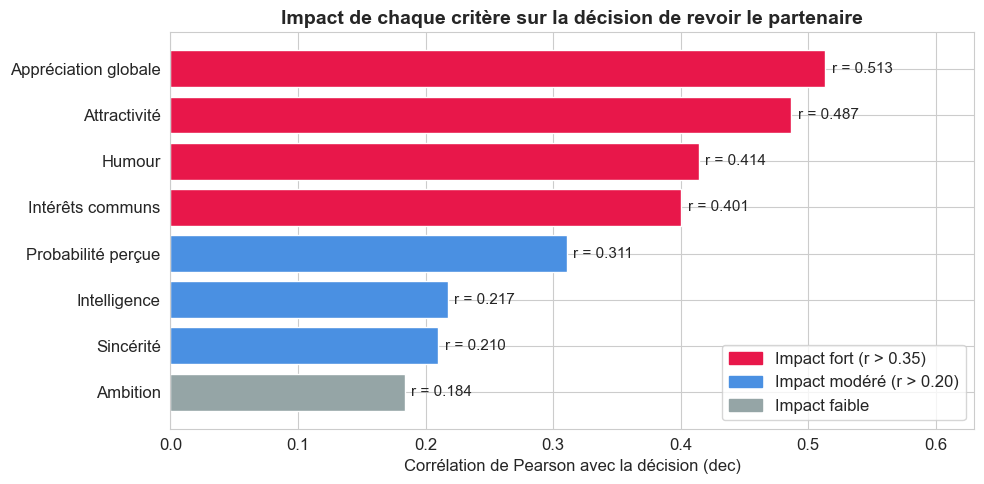

Interprétation :
  → L'appréciation globale (like) et l'attractivité sont les 2 meilleurs prédicteurs
  → L'humour et les intérêts communs ont un impact fort et proche
  → Sincérité, intelligence et ambition ont un impact plus faible dans un contexte de 4 min


In [6]:
all_cols = criteres + ['like', 'prob']
all_labels = labels + ['Appréciation globale', 'Probabilité perçue']

corr_dec = df[all_cols + ['dec']].corr()['dec'].drop('dec').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS['tinder'] if v > 0.35 else COLORS['blue'] if v > 0.2 else COLORS['muted']
              for v in corr_dec.values]
bars = ax.barh(corr_dec.index.map(dict(zip(
    all_cols, all_labels))), corr_dec.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Corrélation de Pearson avec la décision (dec)')
ax.set_title('Impact de chaque critère sur la décision de revoir le partenaire',
             fontsize=14, fontweight='bold')
for bar, val in zip(bars, corr_dec.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'r = {val:.3f}', va='center', fontsize=11)
ax.set_xlim(0, 0.63)

p1 = mpatches.Patch(color=COLORS['tinder'], label='Impact fort (r > 0.35)')
p2 = mpatches.Patch(color=COLORS['blue'],   label='Impact modéré (r > 0.20)')
p3 = mpatches.Patch(color=COLORS['muted'],  label='Impact faible')
ax.legend(handles=[p1, p2, p3], loc='lower right')
plt.tight_layout()
plt.show()

print("Interprétation :")
print("  → L'appréciation globale (like) et l'attractivité sont les 2 meilleurs prédicteurs")
print("  → L'humour et les intérêts communs ont un impact fort et proche")
print("  → Sincérité, intelligence et ambition ont un impact plus faible dans un contexte de 4 min")


### 2.2 Hommes vs Femmes : même hiérarchie ?

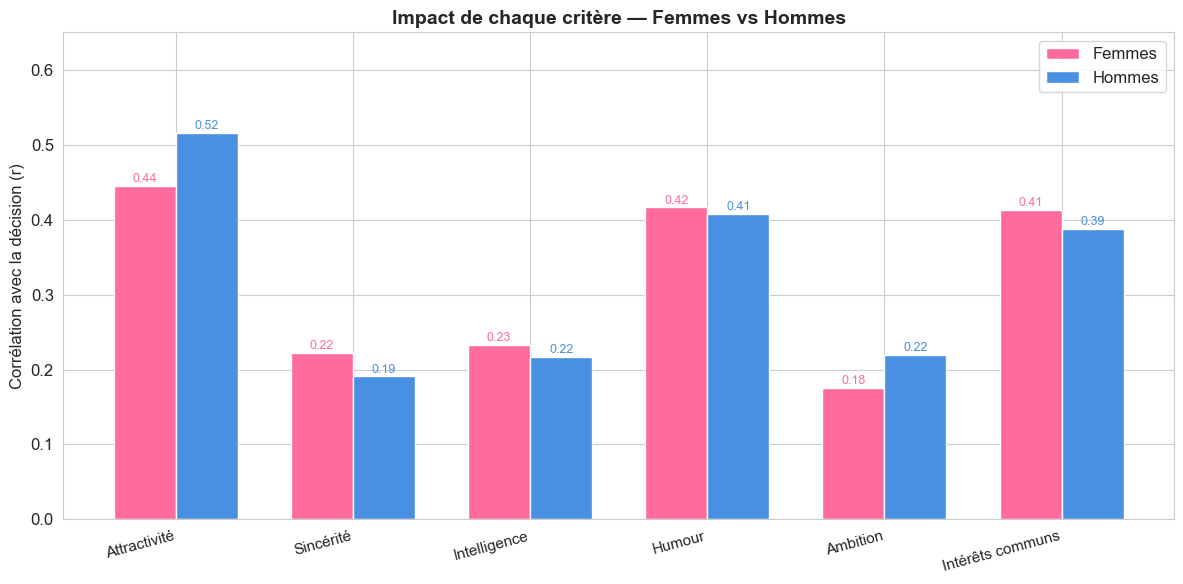

Interprétation :
  → Attractivité : seul critère avec écart significatif (H: 0.515 vs F: 0.445)
  → Humour : quasi-identique (~0.41) — le grand égalisateur
  → Intérêts communs légèrement plus importants pour les femmes (0.413 vs 0.387)
  → Sincérité et intelligence légèrement plus fortes chez les femmes


In [7]:
corr_f = df[df['gender']==0][criteres + ['dec']].corr()['dec'].drop('dec')
corr_m = df[df['gender']==1][criteres + ['dec']].corr()['dec'].drop('dec')

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, corr_f.values, w, label='Femmes', color=COLORS['pink'], edgecolor='white')
b2 = ax.bar(x + w/2, corr_m.values, w, label='Hommes', color=COLORS['blue'], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('Corrélation avec la décision (r)')
ax.set_title('Impact de chaque critère — Femmes vs Hommes', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, 0.65)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color=COLORS['pink'])
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color=COLORS['blue'])
plt.tight_layout()
plt.show()

print("Interprétation :")
print("  → Attractivité : seul critère avec écart significatif (H: 0.515 vs F: 0.445)")
print("  → Humour : quasi-identique (~0.41) — le grand égalisateur")
print("  → Intérêts communs légèrement plus importants pour les femmes (0.413 vs 0.387)")
print("  → Sincérité et intelligence légèrement plus fortes chez les femmes")


### 2.3 Profil des speed dates qui matchent

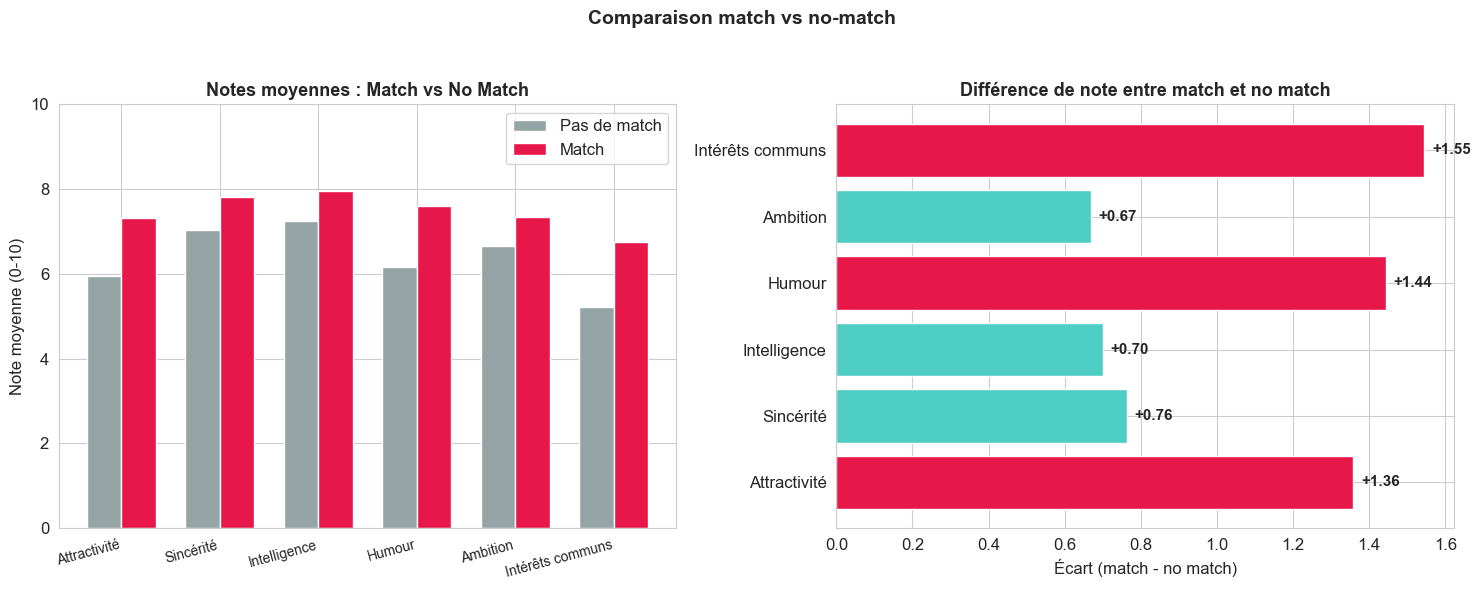

Interprétation :
  → Intérêts communs : plus grand écart (+1.55)
  → Humour (+1.44) et attractivité (+1.36) suivent
  → Ambition et sincérité font la moins grande différence


In [8]:
means_0 = [df[df['match']==0][c].mean() for c in criteres]
means_1 = [df[df['match']==1][c].mean() for c in criteres]
diffs   = [m1 - m0 for m0, m1 in zip(means_0, means_1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, means_0, w, label='Pas de match', color=COLORS['muted'], edgecolor='white')
axes[0].bar(x + w/2, means_1, w, label='Match', color=COLORS['tinder'], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
axes[0].set_ylabel('Note moyenne (0-10)')
axes[0].set_ylim(0, 10)
axes[0].set_title('Notes moyennes : Match vs No Match', fontsize=13, fontweight='bold')
axes[0].legend()

diff_colors = [COLORS['tinder'] if d > 1.2 else COLORS['coral'] if d > 0.8 else COLORS['teal']
               for d in diffs]
axes[1].barh(labels, diffs, color=diff_colors, edgecolor='white')
axes[1].set_xlabel('Écart (match - no match)')
axes[1].set_title('Différence de note entre match et no match', fontsize=13, fontweight='bold')
for i, val in enumerate(diffs):
    axes[1].text(val + 0.02, i, f'+{val:.2f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Comparaison match vs no-match', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interprétation :")
print("  → Intérêts communs : plus grand écart (+1.55)")
print("  → Humour (+1.44) et attractivité (+1.36) suivent")
print("  → Ambition et sincérité font la moins grande différence")


## Étape 3 — Questions clés du brief


### 3.1 Importance perçue vs impact réel de l'attractivité

Avant la soirée, les participants ont réparti 100 points entre les 6 critères (leur importance déclarée).  
On compare ces préférences avec l'impact réel mesuré (corrélation avec `dec`).


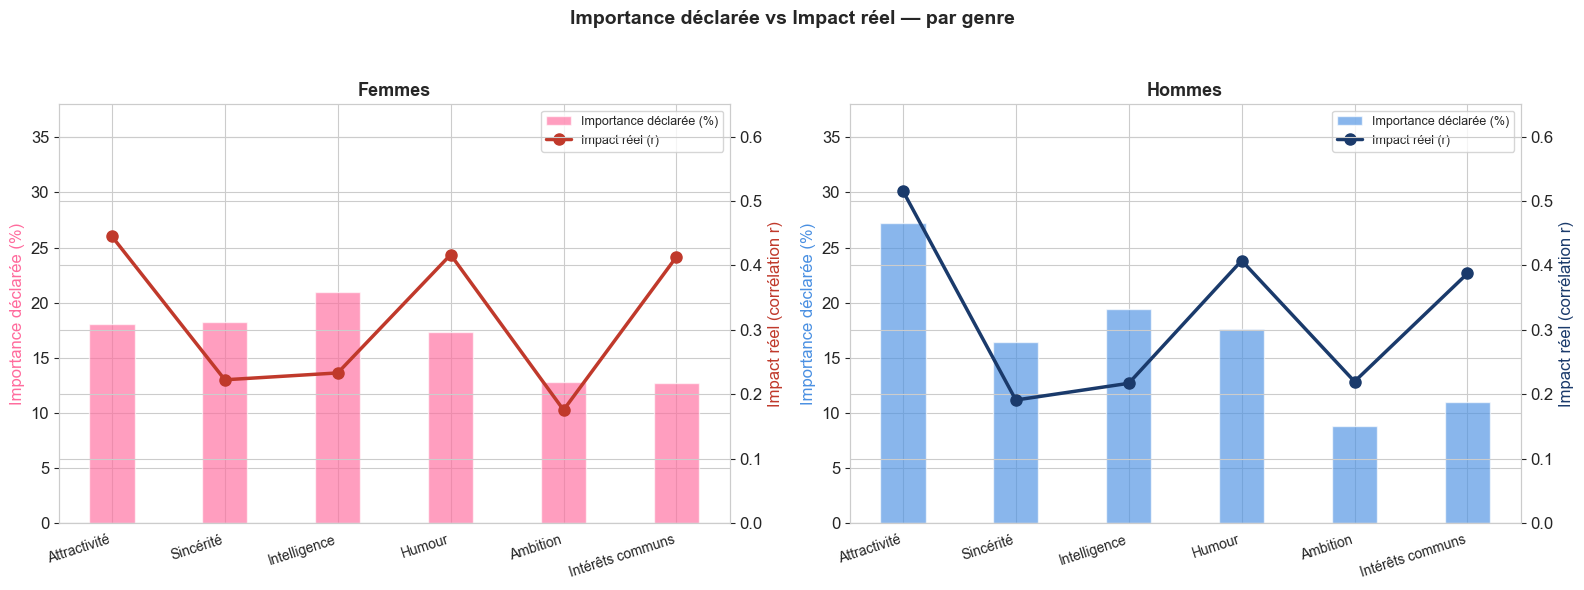

Interprétation :
  → Hommes : déclarent 27% d'attractivité — cohérent avec leur prédicteur réel le plus fort
  → Femmes : déclarent vouloir l'intelligence (21%), mais l'attractivité pèse autant en réalité
  → Les deux genres sous-estiment les intérêts communs (11-13% déclaré vs r~0.40 réel)


In [9]:
pref_cols = ['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1']
pref_f = df[df['gender']==0].drop_duplicates('iid')[pref_cols].mean().values
pref_m = df[df['gender']==1].drop_duplicates('iid')[pref_cols].mean().values
imp_f  = corr_f[criteres].values
imp_m  = corr_m[criteres].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pref, impact, gtitle, c_bar, c_line in [
    (axes[0], pref_f, imp_f, 'Femmes', COLORS['pink'], '#C0392B'),
    (axes[1], pref_m, imp_m, 'Hommes', COLORS['blue'], '#1A3A6B'),
]:
    x = np.arange(len(labels))
    ax2 = ax.twinx()
    ax.bar(x, pref, 0.4, label='Importance déclarée (%)', color=c_bar, alpha=0.65, edgecolor='white')
    ax2.plot(x, impact, 'o-', color=c_line, linewidth=2.5, markersize=8, label='Impact réel (r)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=18, ha='right', fontsize=10)
    ax.set_ylabel('Importance déclarée (%)', color=c_bar)
    ax2.set_ylabel('Impact réel (corrélation r)', color=c_line)
    ax.set_title(f'{gtitle}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 38)
    ax2.set_ylim(0, 0.65)
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, loc='upper right', fontsize=9)

plt.suptitle("Importance déclarée vs Impact réel — par genre", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interprétation :")
print("  → Hommes : déclarent 27% d'attractivité — cohérent avec leur prédicteur réel le plus fort")
print("  → Femmes : déclarent vouloir l'intelligence (21%), mais l'attractivité pèse autant en réalité")
print("  → Les deux genres sous-estiment les intérêts communs (11-13% déclaré vs r~0.40 réel)")


### 3.2 Intérêts communs vs même origine raciale : lequel prédit mieux le match ?

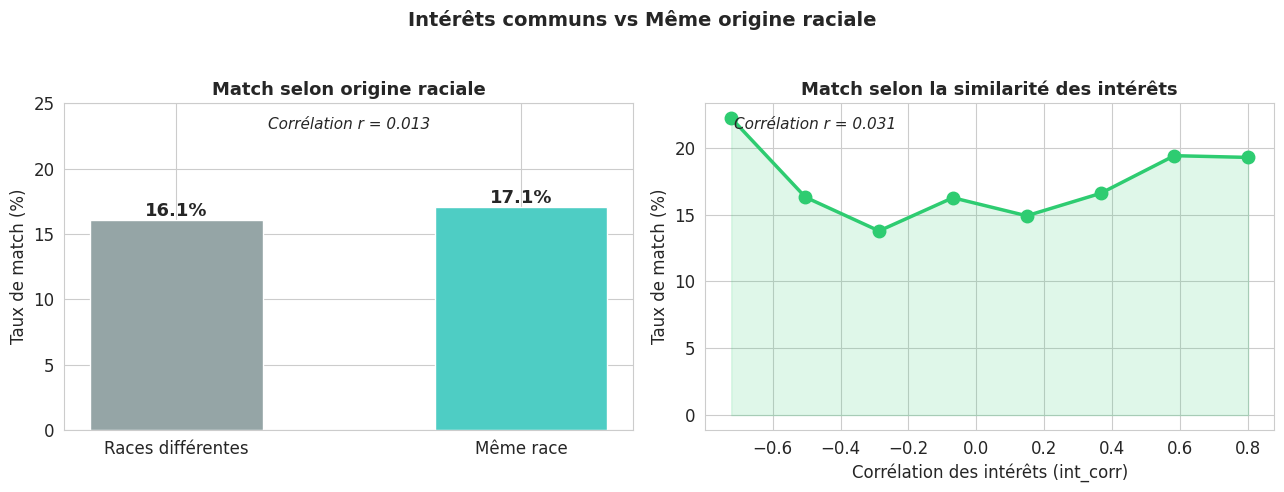

Interprétation :
  → Même race : différence minime (17.1% vs 16.1%), r = 0.013 → quasi nul
  → Intérêts communs : r = 0.031, légèrement plus fort mais toujours faible isolément
  → Conclusion : ni l'un ni l'autre ne prédit bien le match seul
    Les critères interpersonnels (attractivité, humour) dominent largement


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Match selon même race
match_race = df.groupby('samerace')['match'].mean() * 100
axes[0].bar(['Races différentes', 'Même race'], match_race.values,
            color=[COLORS['muted'], COLORS['teal']], edgecolor='white', width=0.5)
axes[0].set_ylabel('Taux de match (%)')
axes[0].set_title('Match selon origine raciale', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 25)
for i, val in enumerate(match_race.values):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].text(0.5, 0.92, 'Corrélation r = 0.013', ha='center', fontsize=11,
             style='italic', transform=axes[0].transAxes)

# Match selon corrélation d'intérêts
bins = pd.cut(df['int_corr'].dropna(), bins=8)
int_match = df.dropna(subset=['int_corr']).groupby(bins)['match'].mean() * 100
x_vals = [float(interval.mid) for interval in int_match.index]
axes[1].plot(x_vals, int_match.values, 'o-', color=COLORS['green'], linewidth=2.5, markersize=9)
axes[1].fill_between(x_vals, int_match.values, alpha=0.15, color=COLORS['green'])
axes[1].set_xlabel('Corrélation des intérêts (int_corr)')
axes[1].set_ylabel('Taux de match (%)')
axes[1].set_title('Match selon la similarité des intérêts', fontsize=13, fontweight='bold')
axes[1].text(0.05, 0.92, 'Corrélation r = 0.031', transform=axes[1].transAxes,
             fontsize=11, style='italic')

plt.suptitle("Intérêts communs vs Même origine raciale", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interprétation :")
print("  → Même race : différence minime (17.1% vs 16.1%), r = 0.013 → quasi nul")
print("  → Intérêts communs : r = 0.031, légèrement plus fort mais toujours faible isolément")
print("  → Conclusion : ni l'un ni l'autre ne prédit bien le match seul")
print("    Les critères interpersonnels (attractivité, humour) dominent largement")


### 3.3 Les participants prédisent-ils bien leur propre valeur sur le marché des rencontres ?

Comparaison entre l'**auto-évaluation avant la soirée** (`attr3_1`, etc.) et les **notes réellement reçues** (`attr`, etc.).


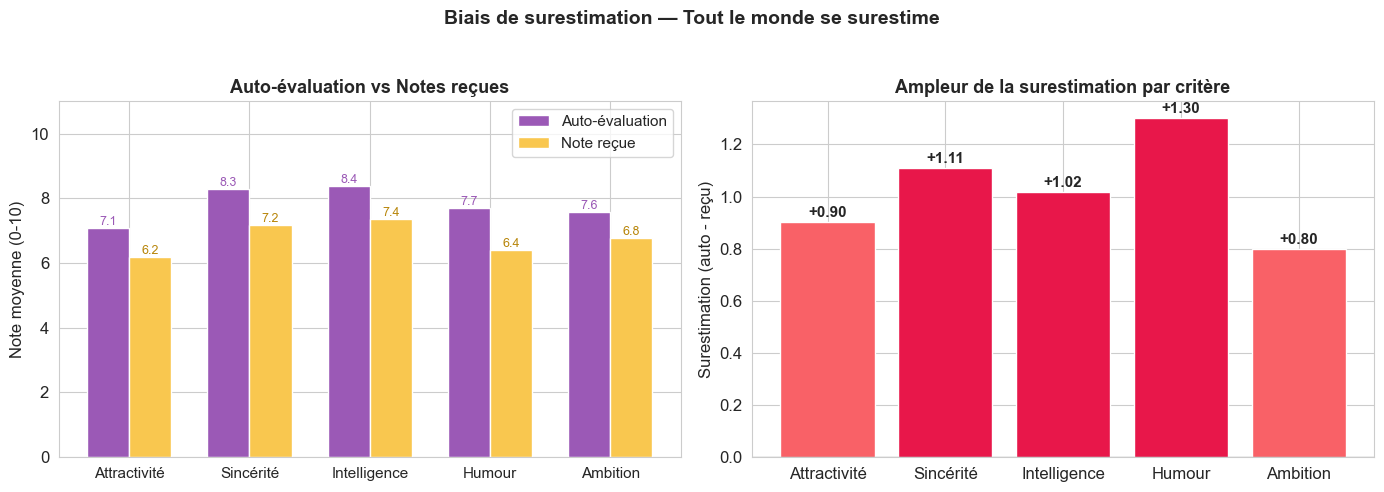

Interprétation :
  → Tous les critères sont surestimés — biais de désirabilité sociale universel
  → Humour : surestimation la plus forte (+1.30) — on se croit plus drôle qu'on ne l'est
  → Sincérité (+1.11) et intelligence (+1.02) suivent
  → Ambition : surestimation la plus faible (+0.80)


In [10]:
self_cols = ['attr3_1','sinc3_1','intel3_1','fun3_1','amb3_1']
recv_cols = criteres[:5]
labels_5  = labels[:5]

self_means = [df.drop_duplicates('iid')[c].mean() for c in self_cols]
recv_means = [df[c].mean() for c in recv_cols]
ecarts     = [s - r for s, r in zip(self_means, recv_means)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(labels_5))
w = 0.35
axes[0].bar(x - w/2, self_means, w, label='Auto-évaluation', color=COLORS['purple'], edgecolor='white')
axes[0].bar(x + w/2, recv_means, w, label='Note reçue',       color=COLORS['gold'],   edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_5, fontsize=11)
axes[0].set_ylabel('Note moyenne (0-10)')
axes[0].set_ylim(0, 11)
axes[0].set_title('Auto-évaluation vs Notes reçues', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
for i in range(len(labels_5)):
    axes[0].text(i - w/2, self_means[i] + 0.1, f'{self_means[i]:.1f}',
                 ha='center', fontsize=9, color=COLORS['purple'])
    axes[0].text(i + w/2, recv_means[i] + 0.1, f'{recv_means[i]:.1f}',
                 ha='center', fontsize=9, color='#B8860B')

ecart_colors = [COLORS['tinder'] if e > 1 else COLORS['coral'] for e in ecarts]
axes[1].bar(labels_5, ecarts, color=ecart_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Surestimation (auto - reçu)')
axes[1].set_title('Ampleur de la surestimation par critère', fontsize=13, fontweight='bold')
for i, val in enumerate(ecarts):
    axes[1].text(i, val + 0.02, f'+{val:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Biais de surestimation — Tout le monde se surestime', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interprétation :")
print("  → Tous les critères sont surestimés — biais de désirabilité sociale universel")
print("  → Humour : surestimation la plus forte (+1.30) — on se croit plus drôle qu'on ne l'est")
print("  → Sincérité (+1.11) et intelligence (+1.02) suivent")
print("  → Ambition : surestimation la plus faible (+0.80)")


### 3.4 Effet de l'ordre — Vaut-il mieux être le premier ou le dernier RDV ?

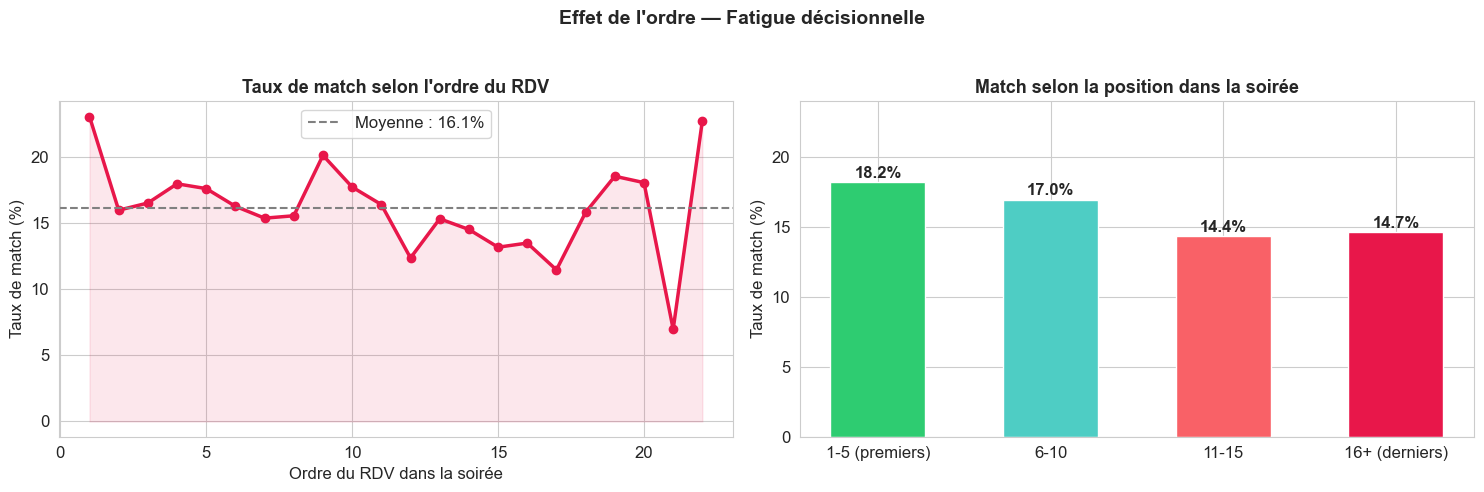

Interprétation :
  → Premiers RDV (ordre 1-5) : 18.2% de match — léger avantage
  → L'effet s'estompe progressivement : 17.0% → 14.4% → 14.7%
  → Hypothèse : fatigue décisionnelle — les participants deviennent plus sélectifs
    (ou moins enthousiastes) après de nombreux RDV successifs


In [11]:
order_match = df.groupby('order')['match'].mean() * 100
order_dec   = df.groupby('order')['dec'].mean() * 100

groupes = {'1-5 (premiers)': (1,5), '6-10': (6,10), '11-15': (11,15), '16+ (derniers)': (16,99)}
taux, labs = [], []
for lab, (lo, hi) in groupes.items():
    taux.append(df[(df['order']>=lo)&(df['order']<=hi)]['match'].mean()*100)
    labs.append(lab)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe par ordre
axes[0].plot(order_match.index, order_match.values, 'o-',
             color=COLORS['tinder'], linewidth=2.5, markersize=6)
axes[0].fill_between(order_match.index, order_match.values, alpha=0.1, color=COLORS['tinder'])
axes[0].axhline(order_match.mean(), color='gray', linestyle='--',
                label=f'Moyenne : {order_match.mean():.1f}%')
axes[0].set_xlabel("Ordre du RDV dans la soirée")
axes[0].set_ylabel("Taux de match (%)")
axes[0].set_title("Taux de match selon l'ordre du RDV", fontsize=13, fontweight='bold')
axes[0].legend()

# Barres par groupe
g_colors = [COLORS['green'], COLORS['teal'], COLORS['coral'], COLORS['tinder']]
bars = axes[1].bar(labs, taux, color=g_colors, edgecolor='white', width=0.55)
axes[1].set_ylabel("Taux de match (%)")
axes[1].set_title("Match selon la position dans la soirée", fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 24)
for bar, val in zip(bars, taux):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle("Effet de l'ordre — Fatigue décisionnelle", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interprétation :")
print("  → Premiers RDV (ordre 1-5) : 18.2% de match — léger avantage")
print("  → L'effet s'estompe progressivement : 17.0% → 14.4% → 14.7%")
print("  → Hypothèse : fatigue décisionnelle — les participants deviennent plus sélectifs")
print("    (ou moins enthousiastes) après de nombreux RDV successifs")


## Étape 4 — Synthèse & Conclusions


### 4.1 Vue d'ensemble — Matrice de corrélations

Corrélations entre les 6 critères d'évaluation et les variables de résultat (`dec`, `match`).


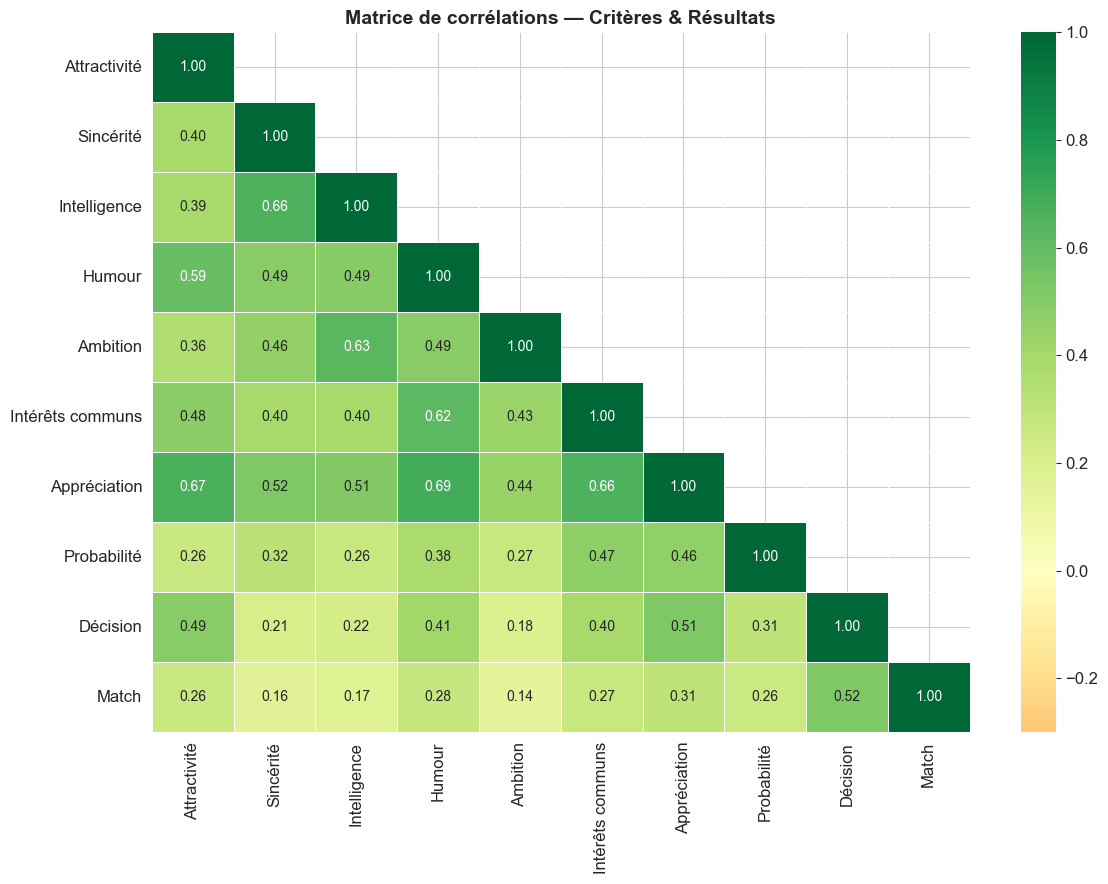

Lecture : la dernière colonne 'Match' et avant-dernière 'Décision' montrent
quels critères prédisent le mieux le résultat.


In [12]:
corr_cols = criteres + ['like', 'prob', 'dec', 'match']
corr_labels = labels + ['Appréciation', 'Probabilité', 'Décision', 'Match']

corr_matrix = df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=1.0,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 10})
ax.set_title('Matrice de corrélations — Critères & Résultats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Lecture : la dernière colonne 'Match' et avant-dernière 'Décision' montrent")
print("quels critères prédisent le mieux le résultat.")


### 4.2 Synthèse visuelle — Ce qui fait matcher

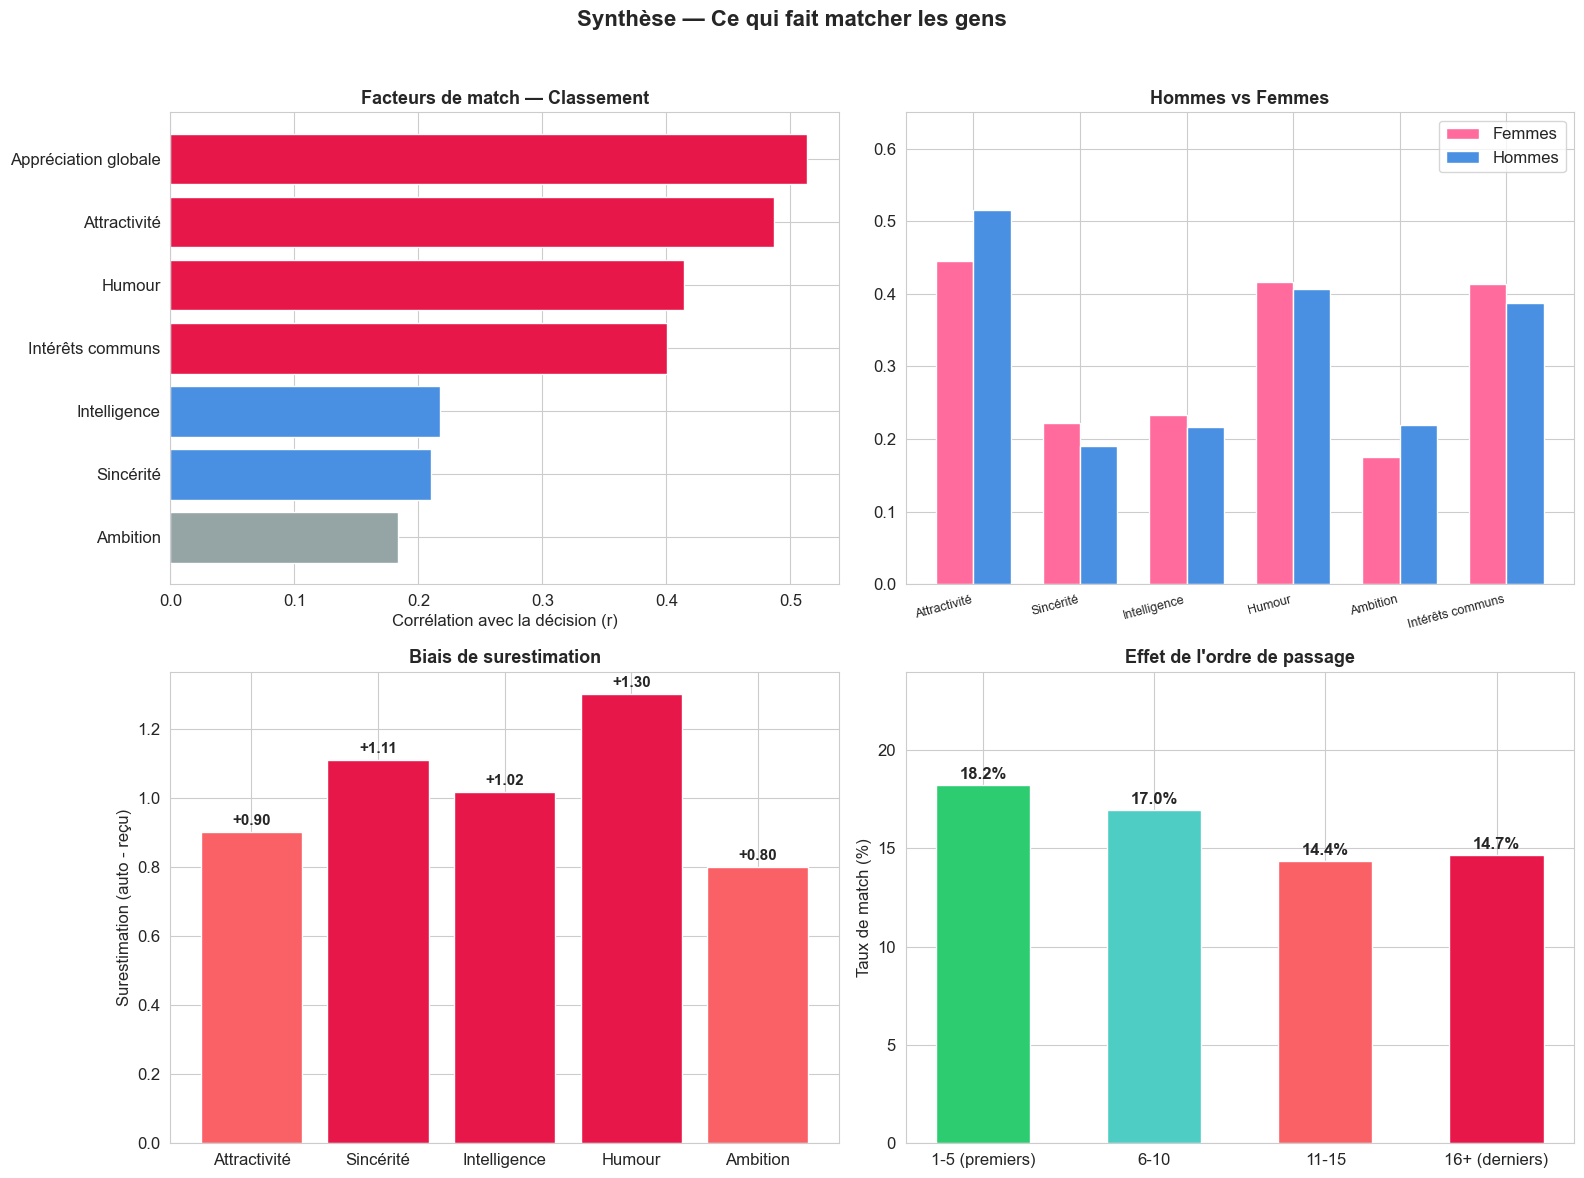

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Graphique 1 : Ranking des corrélations ──
corr_all = df[criteres + ['like', 'dec']].corr()['dec'].drop('dec').sort_values()
bar_colors = [COLORS['tinder'] if v > 0.35 else COLORS['blue'] if v > 0.2 else COLORS['muted']
              for v in corr_all.values]
all_lbl = labels + ['Appréciation globale']
axes[0,0].barh(corr_all.index.map(dict(zip(criteres+['like'], all_lbl))),
               corr_all.values, color=bar_colors, edgecolor='white')
axes[0,0].set_title('Facteurs de match — Classement', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Corrélation avec la décision (r)')

# ── Graphique 2 : H vs F ──
x = np.arange(len(labels))
w = 0.35
axes[0,1].bar(x - w/2, corr_f.values, w, label='Femmes', color=COLORS['pink'], edgecolor='white')
axes[0,1].bar(x + w/2, corr_m.values, w, label='Hommes', color=COLORS['blue'], edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
axes[0,1].set_title('Hommes vs Femmes', fontsize=13, fontweight='bold')
axes[0,1].legend()
axes[0,1].set_ylim(0, 0.65)

# ── Graphique 3 : Surestimation ──
axes[1,0].bar(labels_5, ecarts, color=[COLORS['tinder'] if e>1 else COLORS['coral'] for e in ecarts],
              edgecolor='white')
axes[1,0].set_ylabel('Surestimation (auto - reçu)')
axes[1,0].set_title('Biais de surestimation', fontsize=13, fontweight='bold')
for i, val in enumerate(ecarts):
    axes[1,0].text(i, val + 0.02, f'+{val:.2f}', ha='center', fontweight='bold', fontsize=11)

# ── Graphique 4 : Effet de l'ordre ──
g_colors = [COLORS['green'], COLORS['teal'], COLORS['coral'], COLORS['tinder']]
bars = axes[1,1].bar(labs, taux, color=g_colors, edgecolor='white', width=0.55)
axes[1,1].set_title("Effet de l'ordre de passage", fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Taux de match (%)')
axes[1,1].set_ylim(0, 24)
for bar, val in zip(bars, taux):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle("Synthèse — Ce qui fait matcher les gens", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 4.3 Conclusions

#### Ce qui fait matcher les gens en speed dating

| # | Insight | Chiffres clés |
|---|---------|--------------|
| 1 | **Le feeling immédiat domine** | Attractivité (r=0.49) + appréciation globale (r=0.51) — meilleurs prédicteurs |
| 2 | **L'humour fait la différence** | r≈0.41 chez les deux genres, écart match/no-match le plus fort (+1.44 pts) |
| 3 | **Les intérêts communs sont sous-estimés** | Déclarés à 11–13% mais r≈0.40 en réalité |
| 4 | **Les femmes sont plus sélectives** | 36.5% de "oui" vs 47.4% chez les hommes → filtre principal du match |
| 5 | **Tout le monde se surestime** | +0.80 à +1.30 pts selon le critère — biais de désirabilité sociale |
| 6 | **Être en début de soirée aide** | 18.2% vs 14.4% — effet de fatigue décisionnelle |
| 7 | **La race ne prédit pas le match** | r=0.013 — quasi nul |


#### Recommandations pour Tinder

1. **Valoriser les profils visuels** — L'attractivité est le premier filtre en 4 minutes
2. **Créer des prompts d'humour** — Critère universel H/F avec fort impact réel
3. **Renforcer l'algorithme d'intérêts** — Sous-estimés par les utilisateurs mais fort prédicteur
4. **Développer des formats "live"** — Le speed dating réplique ce que Tinder cherche à recréer

---

*Projet réalisé dans le cadre du Jedha Bootcamp — Bloc de certification n°2*  
*Dataset : Speed Dating Experiment, Columbia Business School (2002–2004)*
